In [4]:
import sys
from pathlib import Path
_root = Path.cwd().parent  # notebooks/ -> project root
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
ROOT = _root

Problème de spatialisation dans la sensation d'elevation,  une HRTF est une empreinte acoustique unique : 

Solutions possibles :

1-  La recherche HRTF (Zotkin 2004, Bilinski 2014) montre que les indices de localisation sont corrélés à quelques mesures physiques mesurables avec un miroir et une règle :

Mesure	            !   Impact sur
Hauteur du pavillon !	Encoches d'élévation (6–16 kHz)
Largeur du pavillon	 ! Fréquence des encoches pinnales
Diamètre de la tête	 ! ITD (délai interaural)
Distance interoculaire	! Approximation de l'ITD
La base IRCAM LISTEN inclut ces mesures anthropométriques pour chaque sujet dans un fichier séparé. Tu mesures les tiennes, tu calcules la distance euclidienne aux sujets, tu prends le plus proche.

2 - Approche Moyenne on génère une HRTF Générique : 

Plutôt que de prendre un seul sujet, on peut calculer la moyenne des magnitudes sur tous les sujets (ou un sous-ensemble). C'est ce que font les HRTFs de têtes artificielles comme le KEMAR ou le KU100.

L'avantage : les encoches individuelles s'estompent, la réponse devient plus "neutre". L'inconvénient : les indices d'élévation s'atténuent aussi.

In [2]:
"http://bili2.ircam.fr/SimpleFreeFieldHRIR/LISTEN/COMPENSATED/44100/contents.html"

'http://bili2.ircam.fr/SimpleFreeFieldHRIR/LISTEN/COMPENSATED/44100/contents.html'

[HRTFGen] 6 fichiers trouvés dans 'dataset/'
[HRTFGen] Chargement de 6 fichiers SOFA...
[HRTF] Convention CW (90deg=droite) detectee -> azimuts convertis en CCW SOFA standard
  ✓  IRC_1002_C_44100.sofa               187 pos  sr=44100 Hz  N=512 smp
[HRTF] Convention CW (90deg=droite) detectee -> azimuts convertis en CCW SOFA standard
  ✓  IRC_1003_C_44100.sofa               187 pos  sr=44100 Hz  N=512 smp
[HRTF] Convention CW (90deg=droite) detectee -> azimuts convertis en CCW SOFA standard
  ✓  IRC_1015_C_44100.sofa               187 pos  sr=44100 Hz  N=512 smp
[HRTF] Convention CW (90deg=droite) detectee -> azimuts convertis en CCW SOFA standard
  ✓  IRC_1042_C_44100.sofa               187 pos  sr=44100 Hz  N=512 smp
[HRTF] Convention CW (90deg=droite) detectee -> azimuts convertis en CCW SOFA standard
  ✓  IRC_1048_C_44100.sofa               187 pos  sr=44100 Hz  N=512 smp
[HRTF] Convention CW (90deg=droite) detectee -> azimuts convertis en CCW SOFA standard
  ✓  IRC_1057_C_44100.sof

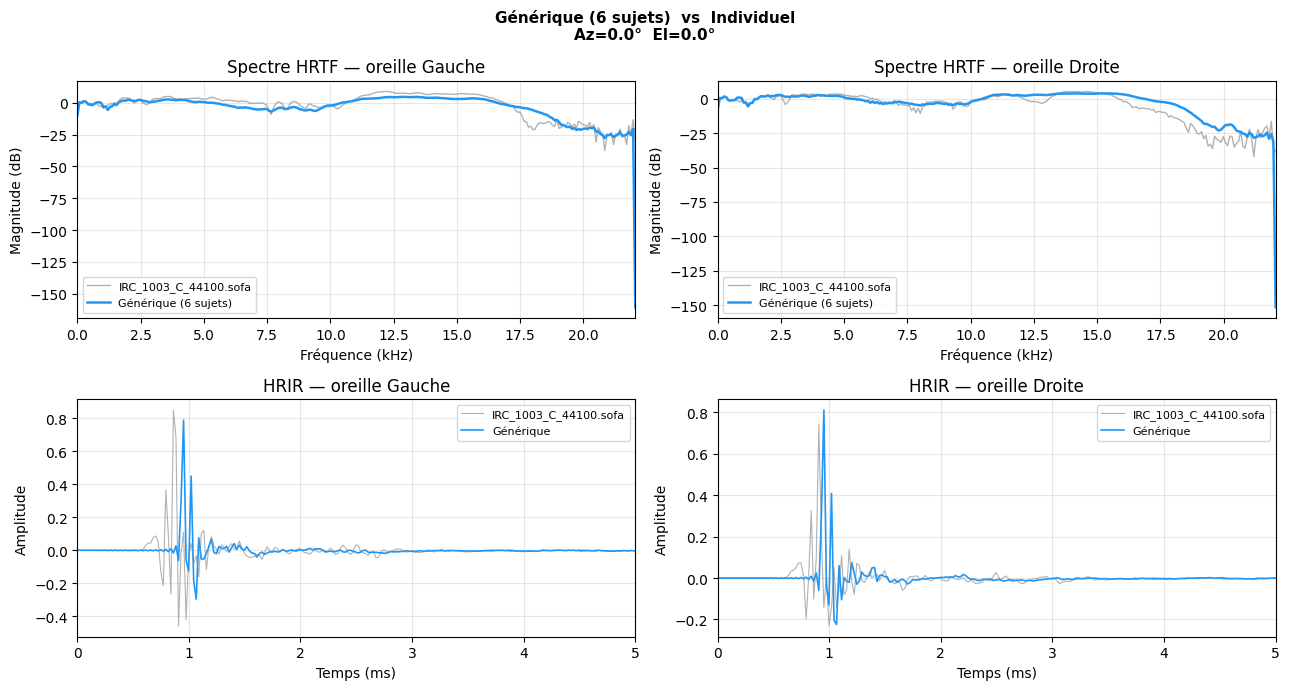

In [13]:
# Une seule fois (~30s pour 51 sujets)
from HRTFGen import HRTFGen
from HRTFInterpolator import HRTFInterpolator
from DynamicConvolver import DynamicConvolver
from hrtf import HRTF

gen = HRTFGen.from_directory(ROOT / "dataset", pattern="IRC_*.sofa")
gen.save(ROOT / "dataset" / "generic.sofa")


# Toutes les fois suivantes — instantané
gen    = HRTFGen.from_sofa(ROOT / "dataset" / "generic.sofa")
interp = HRTFInterpolator(gen)          # drop-in, aucune modification

# Comparaison visuelle générique vs individuel
hrtf_individuel = HRTF.from_sofa(ROOT / "dataset" / "IRC_1003_C_44100.sofa")
gen.plot_comparison(hrtf_individuel, azimuth=0.0, elevation=0.0)
